# Reinforcement-learning raster-to-vector line experiment

This notebook is a comparison version.

It does **not** train directly on the true vector coordinates.

Instead:

1. Synthetic vector lines are generated.
2. They are rasterised into 64×64 images.
3. The model sees only the raster image.
4. The model samples a vector prediction: `[x1, y1, x2, y2]`.
5. The prediction is rasterised.
6. A reward is calculated from how closely the predicted raster matches the input raster.
7. The policy is updated using reinforcement learning.

This is a simple actor-critic / policy-gradient experiment.


In [1]:
# ============================
# 1. Imports and settings
# ============================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from PIL import Image, ImageDraw

print("TensorFlow version:", tf.__version__)

IMG_SIZE = 64

N_TRAIN = 3000
N_TEST = 500

BATCH_SIZE = 64

# Start small to check it works, then increase later
RL_EPOCHS = 100

# This controls how soft/thick the reward raster is.
# Smaller = thinner line, harder reward.
# Bigger = blurrier line, easier reward.
RASTER_SIGMA = 0.012

# Entropy encourages exploration.
# If predictions get stuck too early, increase slightly.
ENTROPY_BONUS = 0.001

# Value loss weight for actor-critic baseline
VALUE_LOSS_WEIGHT = 0.5


TensorFlow version: 2.21.0


In [2]:
# ============================
# 2. Synthetic line data
# ============================

def create_line_image():
    # Random line coordinates
    x1, y1 = np.random.randint(0, IMG_SIZE, size=2)
    x2, y2 = np.random.randint(0, IMG_SIZE, size=2)

    # Avoid extremely tiny lines
    while abs(x2 - x1) + abs(y2 - y1) < 10:
        x2, y2 = np.random.randint(0, IMG_SIZE, size=2)

    image = Image.new("L", (IMG_SIZE, IMG_SIZE), color=255)
    draw = ImageDraw.Draw(image)

    # Black line on white background
    draw.line((x1, y1, x2, y2), fill=0, width=1)

    image_array = np.array(image).astype("float32") / 255.0
    image_array = np.expand_dims(image_array, axis=-1)

    label = np.array([
        x1 / (IMG_SIZE - 1),
        y1 / (IMG_SIZE - 1),
        x2 / (IMG_SIZE - 1),
        y2 / (IMG_SIZE - 1)
    ], dtype="float32")

    return image_array, label


def create_dataset(n_samples):
    images = []
    labels = []

    for _ in range(n_samples):
        image, label = create_line_image()
        images.append(image)
        labels.append(label)

    return np.array(images), np.array(labels)


X_train, y_train = create_dataset(N_TRAIN)
X_test, y_test = create_dataset(N_TEST)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


X_train: (3000, 64, 64, 1)
y_train: (3000, 4)
X_test: (500, 64, 64, 1)
y_test: (500, 4)


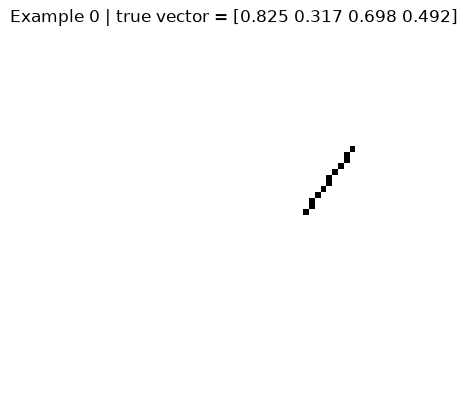

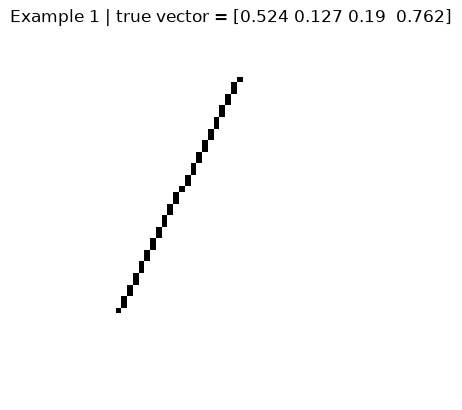

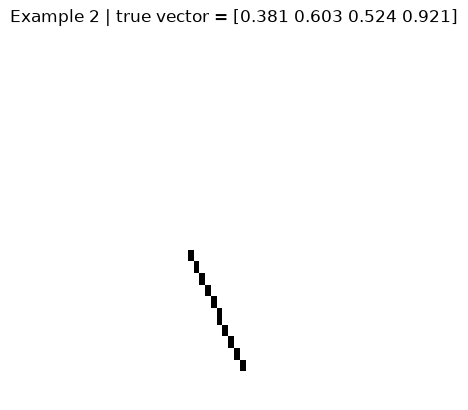

In [3]:
# ============================
# 3. Show some examples
# ============================

for i in range(3):
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(f"Example {i} | true vector = {np.round(y_train[i], 3)}")
    plt.axis("off")
    plt.show()


In [4]:
# ============================
# 4. TensorFlow rasteriser used for reward
# ============================

class SoftLineRasteriser(layers.Layer):
    def __init__(self, img_size=64, sigma=0.012, **kwargs):
        super().__init__(**kwargs)
        self.img_size = img_size
        self.sigma = sigma

        xs = tf.linspace(0.0, 1.0, img_size)
        ys = tf.linspace(0.0, 1.0, img_size)

        grid_x, grid_y = tf.meshgrid(xs, ys)

        self.grid_x = tf.reshape(grid_x, (1, img_size, img_size))
        self.grid_y = tf.reshape(grid_y, (1, img_size, img_size))

    def call(self, vectors):
        x1 = tf.reshape(vectors[:, 0], (-1, 1, 1))
        y1 = tf.reshape(vectors[:, 1], (-1, 1, 1))
        x2 = tf.reshape(vectors[:, 2], (-1, 1, 1))
        y2 = tf.reshape(vectors[:, 3], (-1, 1, 1))

        px = self.grid_x
        py = self.grid_y

        dx = x2 - x1
        dy = y2 - y1

        length_squared = dx * dx + dy * dy + 1e-8

        t = ((px - x1) * dx + (py - y1) * dy) / length_squared
        t = tf.clip_by_value(t, 0.0, 1.0)

        closest_x = x1 + t * dx
        closest_y = y1 + t * dy

        distance_squared = tf.square(px - closest_x) + tf.square(py - closest_y)

        # 1 = dark line, 0 = background
        line_darkness = tf.exp(-distance_squared / (2.0 * self.sigma * self.sigma))

        # Convert to image format:
        # 0 = black line, 1 = white background
        raster = 1.0 - line_darkness

        return tf.expand_dims(raster, axis=-1)


rasteriser = SoftLineRasteriser(img_size=IMG_SIZE, sigma=RASTER_SIGMA)


In [5]:
# ============================
# 5. Reward function
# ============================

def calculate_reward(target_images, predicted_vectors):
    '''
    target_images:
        Original raster images, shape (batch, 64, 64, 1)

    predicted_vectors:
        Sampled vector actions, shape (batch, 4)

    returns:
        reward, shape (batch,)
    '''

    predicted_images = rasteriser(predicted_vectors)

    # The line pixels are rare, so ordinary MSE is too dominated by white background.
    # This gives more weight to dark line pixels in the target.
    line_weight = 1.0 + 20.0 * (1.0 - target_images)

    mse = tf.reduce_mean(
        line_weight * tf.square(target_images - predicted_images),
        axis=[1, 2, 3]
    )

    # Higher reward is better.
    # The scale factor makes small changes easier to see.
    reward = tf.exp(-80.0 * mse)

    return reward


In [6]:
# ============================
# 6. Actor-critic model
# ============================

class RLVectorAgent(tf.keras.Model):
    def __init__(self):
        super().__init__()

        self.feature_extractor = models.Sequential([
            layers.Input(shape=(64, 64, 1)),

            layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),

            layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),

            layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),

            layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
            layers.Flatten(),

            layers.Dense(256, activation="relu"),
            layers.Dense(128, activation="relu"),
        ])

        # Actor: mean vector prediction
        self.mean_head = layers.Dense(4, activation="sigmoid")

        # Critic: predicts expected reward
        self.value_head = layers.Dense(1)

        # Trainable action noise.
        # Starts with quite a lot of exploration.
        self.log_std = tf.Variable(
            initial_value=tf.ones((4,), dtype=tf.float32) * -1.0,
            trainable=True,
            name="log_std"
        )

    def call(self, images):
        features = self.feature_extractor(images)
        means = self.mean_head(features)
        values = self.value_head(features)
        return means, values

    def sample_action(self, images):
        means, values = self(images)

        std = tf.exp(self.log_std)

        noise = tf.random.normal(shape=tf.shape(means))
        raw_actions = means + noise * std

        # Keep coordinates between 0 and 1
        actions = tf.clip_by_value(raw_actions, 0.0, 1.0)

        # Log probability under normal distribution
        log_probs = -0.5 * tf.square((raw_actions - means) / (std + 1e-8))
        log_probs -= tf.math.log(std + 1e-8)
        log_probs -= 0.5 * tf.math.log(2.0 * np.pi)
        log_probs = tf.reduce_sum(log_probs, axis=1)

        entropy = tf.reduce_sum(
            0.5 * tf.math.log(2.0 * np.pi * np.e * tf.square(std)),
            axis=-1
        )

        return actions, log_probs, values, entropy


agent = RLVectorAgent()

# Build model once
dummy = tf.zeros((1, IMG_SIZE, IMG_SIZE, 1))
_ = agent(dummy)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)

print("Agent built.")


Agent built.


In [7]:
# ============================
# 7. One reinforcement-learning train step
# ============================

@tf.function
def train_step(batch_images):
    with tf.GradientTape() as tape:
        actions, log_probs, values, entropy = agent.sample_action(batch_images)

        # Reward is based on how well the sampled vector recreates the input raster.
        rewards = calculate_reward(batch_images, actions)

        # Stop gradients through the reward.
        # This makes it reinforcement learning, not normal backprop through the rasteriser.
        rewards_stopped = tf.stop_gradient(rewards)

        values = tf.squeeze(values, axis=1)

        advantages = rewards_stopped - values

        actor_loss = -tf.reduce_mean(log_probs * tf.stop_gradient(advantages))

        critic_loss = tf.reduce_mean(tf.square(rewards_stopped - values))

        entropy_loss = -ENTROPY_BONUS * entropy

        total_loss = actor_loss + VALUE_LOSS_WEIGHT * critic_loss + entropy_loss

    gradients = tape.gradient(total_loss, agent.trainable_variables)
    optimizer.apply_gradients(zip(gradients, agent.trainable_variables))

    return total_loss, actor_loss, critic_loss, tf.reduce_mean(rewards), tf.reduce_mean(values)


In [8]:
# ============================
# 8. Train the reinforcement model
# ============================

train_dataset = tf.data.Dataset.from_tensor_slices(X_train)
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

rl_history = {
    "loss": [],
    "actor_loss": [],
    "critic_loss": [],
    "reward": [],
    "value": []
}

for epoch in range(RL_EPOCHS):
    epoch_losses = []
    epoch_actor = []
    epoch_critic = []
    epoch_rewards = []
    epoch_values = []

    for batch_images in train_dataset:
        total_loss, actor_loss, critic_loss, mean_reward, mean_value = train_step(batch_images)

        epoch_losses.append(float(total_loss))
        epoch_actor.append(float(actor_loss))
        epoch_critic.append(float(critic_loss))
        epoch_rewards.append(float(mean_reward))
        epoch_values.append(float(mean_value))

    rl_history["loss"].append(np.mean(epoch_losses))
    rl_history["actor_loss"].append(np.mean(epoch_actor))
    rl_history["critic_loss"].append(np.mean(epoch_critic))
    rl_history["reward"].append(np.mean(epoch_rewards))
    rl_history["value"].append(np.mean(epoch_values))

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1:03d}/{RL_EPOCHS} | "
            f"loss={rl_history['loss'][-1]:.4f} | "
            f"reward={rl_history['reward'][-1]:.4f} | "
            f"value={rl_history['value'][-1]:.4f}"
        )


Epoch 001/100 | loss=-0.0019 | reward=0.0010 | value=0.0014
Epoch 005/100 | loss=-0.0019 | reward=0.0010 | value=0.0010
Epoch 010/100 | loss=-0.0017 | reward=0.0010 | value=0.0010
Epoch 015/100 | loss=-0.0018 | reward=0.0008 | value=0.0008
Epoch 020/100 | loss=-0.0019 | reward=0.0008 | value=0.0008
Epoch 025/100 | loss=-0.0018 | reward=0.0008 | value=0.0009
Epoch 030/100 | loss=-0.0018 | reward=0.0011 | value=0.0010
Epoch 035/100 | loss=-0.0019 | reward=0.0009 | value=0.0009
Epoch 040/100 | loss=-0.0018 | reward=0.0010 | value=0.0010
Epoch 045/100 | loss=-0.0017 | reward=0.0009 | value=0.0008
Epoch 050/100 | loss=-0.0016 | reward=0.0009 | value=0.0010
Epoch 055/100 | loss=-0.0020 | reward=0.0010 | value=0.0010
Epoch 060/100 | loss=-0.0018 | reward=0.0008 | value=0.0008
Epoch 065/100 | loss=-0.0018 | reward=0.0012 | value=0.0012
Epoch 070/100 | loss=-0.0019 | reward=0.0007 | value=0.0008
Epoch 075/100 | loss=-0.0018 | reward=0.0009 | value=0.0008
Epoch 080/100 | loss=-0.0018 | reward=0.

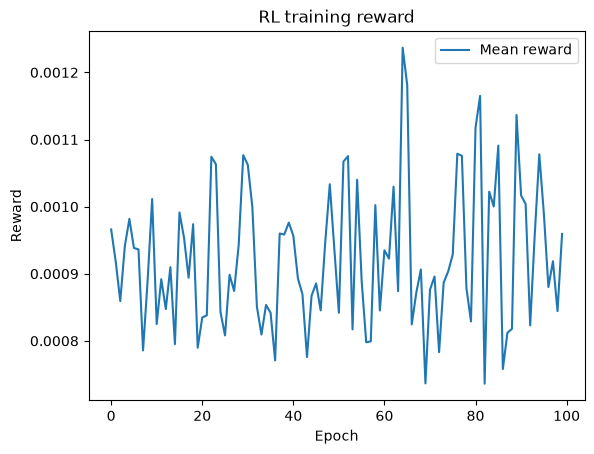

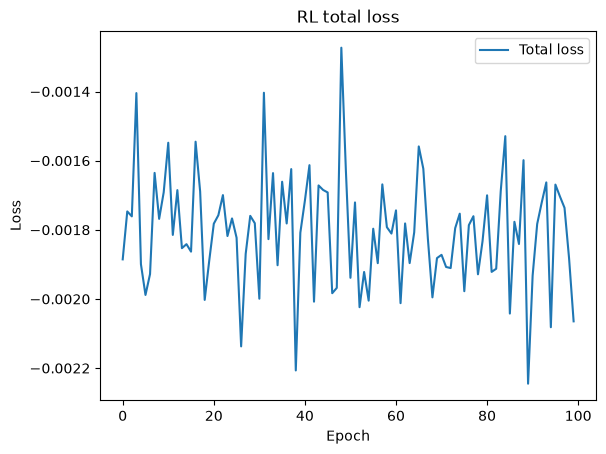

In [9]:
# ============================
# 9. Plot reinforcement learning reward
# ============================

plt.plot(rl_history["reward"], label="Mean reward")
plt.xlabel("Epoch")
plt.ylabel("Reward")
plt.title("RL training reward")
plt.legend()
plt.show()

plt.plot(rl_history["loss"], label="Total loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RL total loss")
plt.legend()
plt.show()


In [10]:
# ============================
# 10. Helper functions for testing and display
# ============================

def hard_rasterise_line(vector):
    x1, y1, x2, y2 = (vector * (IMG_SIZE - 1)).astype(int)

    image = Image.new("L", (IMG_SIZE, IMG_SIZE), color=255)
    draw = ImageDraw.Draw(image)
    draw.line((x1, y1, x2, y2), fill=0, width=1)

    return np.array(image).astype("float32") / 255.0


def predict_mean_vector(image):
    image_batch = image[None, ...].astype("float32")
    means, values = agent(image_batch)
    return means.numpy()[0], values.numpy()[0, 0]


def display_prediction(index=0):
    image = X_test[index]
    true_vector = y_test[index]

    predicted_vector, predicted_value = predict_mean_vector(image)

    predicted_soft = rasteriser(tf.constant(predicted_vector[None, :], dtype=tf.float32)).numpy()[0]
    predicted_hard = hard_rasterise_line(predicted_vector)

    reward = calculate_reward(
        tf.constant(image[None, ...], dtype=tf.float32),
        tf.constant(predicted_vector[None, :], dtype=tf.float32)
    ).numpy()[0]

    print("True vector:     ", np.round(true_vector, 3))
    print("Predicted vector:", np.round(predicted_vector, 3))
    print("True pixels:     ", (true_vector * (IMG_SIZE - 1)).astype(int))
    print("Predicted pixels:", (predicted_vector * (IMG_SIZE - 1)).astype(int))
    print("Reward:", round(float(reward), 4))
    print("Critic value prediction:", round(float(predicted_value), 4))

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title("Input raster")
    plt.axis("off")
    plt.show()

    plt.imshow(predicted_soft.squeeze(), cmap="gray")
    plt.title("Soft rasterised policy output")
    plt.axis("off")
    plt.show()

    plt.imshow(predicted_hard, cmap="gray")
    plt.title("Hard rasterised vector output")
    plt.axis("off")
    plt.show()


True vector:      [0.27  0.048 0.048 0.413]
Predicted vector: [0.502 0.501 0.497 0.502]
True pixels:      [17  3  3 26]
Predicted pixels: [31 31 31 31]
Reward: 0.0001
Critic value prediction: -0.0009


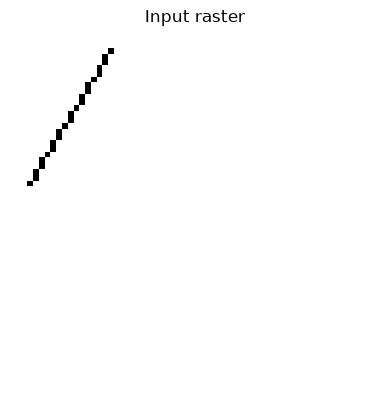

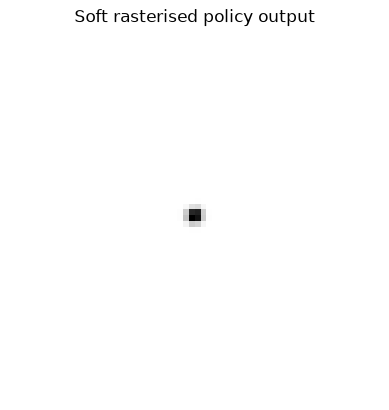

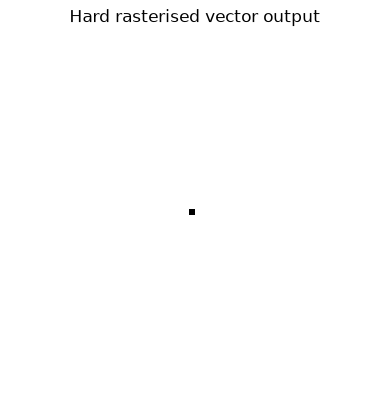

True vector:      [0.698 0.27  0.841 0.794]
Predicted vector: [0.502 0.5   0.5   0.5  ]
True pixels:      [44 17 53 50]
Predicted pixels: [31 31 31 31]
Reward: 0.0
Critic value prediction: 0.0002


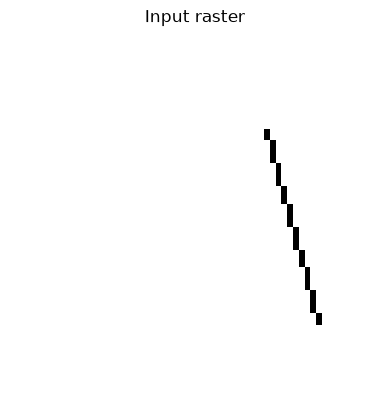

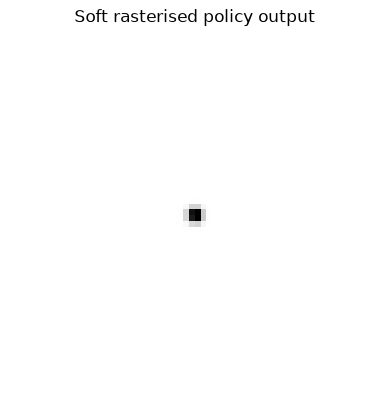

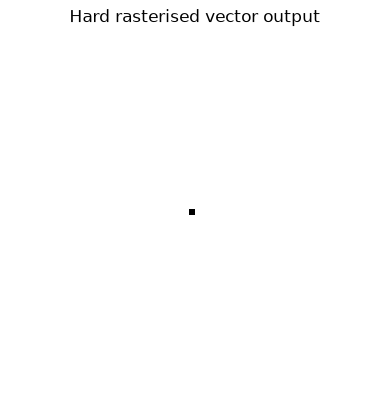

True vector:      [0.111 0.016 0.968 0.444]
Predicted vector: [0.505 0.5   0.496 0.504]
True pixels:      [ 7  1 61 28]
Predicted pixels: [31 31 31 31]
Reward: 0.0
Critic value prediction: -0.0007


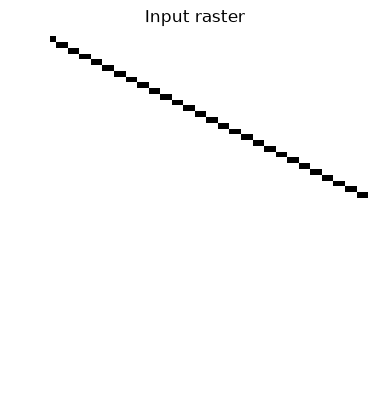

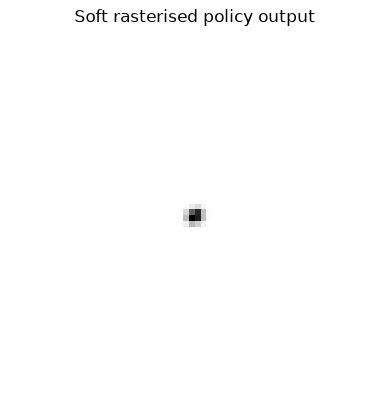

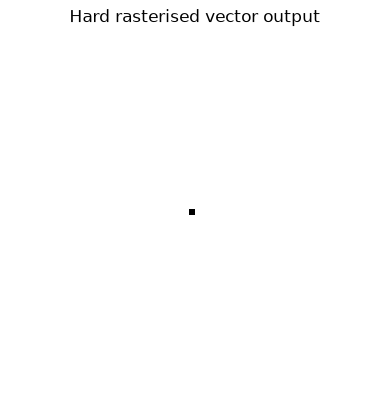

In [11]:
# ============================
# 11. Test some predictions
# ============================

display_prediction(0)
display_prediction(1)
display_prediction(2)


This model suffers from simmilar issues to the first prototype CNN in that it's "lazy" and fails to detect lines, just working out that most squares are white.

In [12]:
# ============================
# 12. Compare average reward on test set
# ============================

test_images = tf.constant(X_test[:200], dtype=tf.float32)
mean_vectors, value_predictions = agent(test_images)

test_rewards = calculate_reward(test_images, mean_vectors)

print("Mean test reward:", float(tf.reduce_mean(test_rewards)))
print("Min test reward: ", float(tf.reduce_min(test_rewards)))
print("Max test reward: ", float(tf.reduce_max(test_rewards)))


Mean test reward: 0.0024322529789060354
Min test reward:  8.597780473684757e-12
Max test reward:  0.05455699935555458
